### Installations

In [1]:
%pip install opencv-python mediapipe numpy matplotlib tqdm
%pip install ipywidgets


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached widgetsnbextension-4.0.15-py3-none-any.whl.metadata (1.6 kB)
  Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl.metadata (20 kB)
Using cached ipywidgets-8.1.8-py3-none-any.whl (139 kB)
Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl (914 kB)
Using cached widgetsnbextension-4.0.15-py3-none-any.whl (2.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [ipywidgets]

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Imports and Configuration

In [2]:
import cv2
import mediapipe as mp
import os
import json
import random
import copy
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm

# --- Configuration ---
INPUT_DIR = Path("../data/raw")
OUTPUT_DIR = Path("../data/processed")

# --- Initialize MediaPipe Pose ---
mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils

pose = mp_pose.Pose(
    static_image_mode=False, 
    model_complexity=2, 
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

print("MediaPipe initialized and configuration set.")

AttributeError: module 'mediapipe' has no attribute 'solutions'

### Core Extraction Function

In [3]:
def process_video(video_path, output_path):
    """Runs MediaPipe over a video and extracts 33 3D world coordinates."""
    # Convert Path object to string for cv2
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return False

    video_data = {
        "video_path": str(video_path),
        "fps": cap.get(cv2.CAP_PROP_FPS),
        "frames": []
    }

    frame_idx = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        
        image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = pose.process(image_rgb)
        
        frame_data = {"frame_index": frame_idx, "landmarks": None}
        
        # Extract 3D world landmarks (x, y, z in meters)
        if results.pose_world_landmarks:
            landmarks = []
            for lm in results.pose_world_landmarks.landmark:
                landmarks.append([lm.x, lm.y, lm.z, lm.visibility])
            frame_data["landmarks"] = landmarks
        
        video_data["frames"].append(frame_data)
        frame_idx += 1

    cap.release()

    # Save to JSON
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    with open(output_path, 'w') as f:
        json.dump(video_data, f)
        
    return True

INFO: 

### Sanity Check Visualization

Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1777098557.399303 4832925 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1777098557.462038 4832926 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
/opt/homebrew/lib/python3.11/site-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


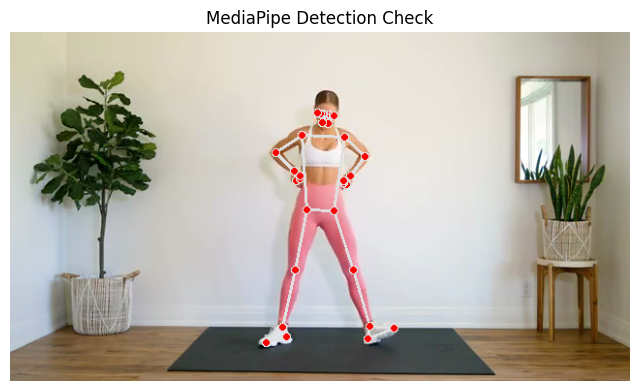

In [4]:
def verify_pose(video_path):
    """Displays a single frame with superimposed landmarks."""
    if not os.path.exists(video_path):
        print(f"File not found: {video_path}\nPlease update the test_video_path.")
        return

    cap = cv2.VideoCapture(str(video_path))
    ret, frame = cap.read()
    if ret:
        image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = pose.process(image_rgb)
        
        if results.pose_landmarks:
            annotated_image = frame.copy()
            mp_drawing.draw_landmarks(
                annotated_image, 
                results.pose_landmarks, 
                mp_pose.POSE_CONNECTIONS
            )
            
            plt.figure(figsize=(8,8))
            plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
            plt.title("MediaPipe Detection Check")
            plt.axis('off')
            plt.show()
        else:
            print("No pose detected in the first frame.")
    cap.release()

test_video_path = INPUT_DIR / "squat" / "RepCount" / "stu1_67.mp4" 
verify_pose(test_video_path)

### Batch Processing Execution

In [5]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Gather all videos dynamically based on the folder structure
target_videos = []

# Iterate through exercises (squat, push_up, etc.)
for exercise_dir in INPUT_DIR.iterdir():
    if exercise_dir.is_dir():
        exercise_class = exercise_dir.name
        
        # Iterate through datasets (Abdillah, RepCount, etc.)
        for dataset_dir in exercise_dir.iterdir():
            if dataset_dir.is_dir():
                dataset_name = dataset_dir.name
                
                # Grab all videos in this specific dataset folder
                for video_path in dataset_dir.glob('*'):
                    if video_path.suffix.lower() in ['.mp4', '.avi', '.mov', '.mkv']:
                        target_videos.append({
                            "path": video_path,
                            "exercise": exercise_class,
                            "dataset": dataset_name
                        })

print(f"Found {len(target_videos)} videos in the curated structure.")

# Process the filtered videos with a progress bar
processed_count = 0
skipped_count = 0
error_count = 0

for vid_info in tqdm(target_videos, desc="Extracting Landmarks"):
    video_path = vid_info["path"]
    exercise_class = vid_info["exercise"]
    dataset_name = vid_info["dataset"]
    
    # Mirror the input structure in the output directory: 
    # processed/<exercise>/<dataset>/<filename>.json
    class_output_dir = OUTPUT_DIR / exercise_class / dataset_name
    class_output_dir.mkdir(parents=True, exist_ok=True)
    
    # Change extension from .mp4 to .json
    output_path = class_output_dir / f"{video_path.stem}.json"
    
    if not output_path.exists():
        success = process_video(video_path, output_path)
        if success:
            processed_count += 1
        else:
            error_count += 1
    else:
        skipped_count += 1

print("\n--- Extraction Complete ---")
print(f"Processed: {processed_count}")
print(f"Skipped (Already Existed): {skipped_count}")
print(f"Errors (Unreadable Videos): {error_count}")

Found 814 videos in the curated structure.


Extracting Landmarks:   0%|          | 0/814 [00:00<?, ?it/s]


--- Extraction Complete ---
Processed: 236
Skipped (Already Existed): 578
Errors (Unreadable Videos): 0


### Dataset Balance Checker

In [6]:
PROCESSED_DIR = Path("../data/processed")
TARGET_COUNT = 250

def check_balance_and_augmentation(data_dir, target_count):
    if not data_dir.exists():
        print(f"Error: Directory '{data_dir}' not found. Please verify the path.")
        return

    counts = {}
    
    # Iterate through each exercise directory
    for exercise_folder in data_dir.iterdir():
        # Exclude hidden system files or directories
        if exercise_folder.is_dir() and not exercise_folder.name.startswith('.'):
            exercise_name = exercise_folder.name
            
            # Recursively count all JSON files within the exercise directory
            json_count = len(list(exercise_folder.rglob("*.json")))
            counts[exercise_name] = json_count

    # Format and display the results
    if counts:
        df = pd.DataFrame(list(counts.items()), columns=['Exercise Class', 'Valid JSONs'])
        df = df.sort_values(by='Valid JSONs', ascending=False).reset_index(drop=True)
        
        print("=========================================")
        print(f"       DATASET BALANCE REPORT            ")
        print(f"       (Target: {target_count} per class)")
        print("=========================================")
        print(df.to_string())
        print("-----------------------------------------\n")
        
        total_videos = df['Valid JSONs'].sum()
        print(f"Total processed files: {total_videos}\n")
        
        print("=========================================")
        print("         AUGMENTATION TARGETS            ")
        print("=========================================")
        for index, row in df.iterrows():
            current_count = row['Valid JSONs']
            shortfall = target_count - current_count
            exercise_name = row['Exercise Class']
            
            if shortfall <= 0:
                print(f"Target Met: '{exercise_name}' contains {current_count} instances. No augmentation required.")
            else:
                if current_count > 0:
                    multiplier = target_count / current_count
                    print(f"Deficit: '{exercise_name}' requires {shortfall} additional instances. (Expansion multiplier: {multiplier:.2f}x)")
                else:
                    print(f"Deficit: '{exercise_name}' contains 0 instances. Cannot calculate expansion multiplier.")
    else:
        print("Notice: No JSON files were found in the specified directory.")

# Execute the function
check_balance_and_augmentation(PROCESSED_DIR, TARGET_COUNT)

       DATASET BALANCE REPORT            
       (Target: 250 per class)
  Exercise Class  Valid JSONs
0        push_up          272
1          squat          252
2    bench_press          162
3        pull_up          128
-----------------------------------------

Total processed files: 814

         AUGMENTATION TARGETS            
Target Met: 'push_up' contains 272 instances. No augmentation required.
Target Met: 'squat' contains 252 instances. No augmentation required.
Deficit: 'bench_press' requires 88 additional instances. (Expansion multiplier: 1.54x)
Deficit: 'pull_up' requires 122 additional instances. (Expansion multiplier: 1.95x)


### Automated Data Augmentation Pipeline

In [8]:
PROCESSED_DIR = Path("../data/processed")
TARGET_COUNT = 250

def augment_noise(data):
    """Injects minor Gaussian noise to simulate tracking inaccuracies."""
    aug_data = copy.deepcopy(data)
    for frame in aug_data.get('frames', []):
        if not isinstance(frame, dict):
            continue
            
        landmarks = frame.get('landmarks')
        # Skip if landmarks is None or empty
        if not landmarks:
            continue
            
        for lm in landmarks:
            if isinstance(lm, dict) and all(k in lm for k in ('x', 'y', 'z')):
                lm['x'] += random.gauss(0, 0.01)
                lm['y'] += random.gauss(0, 0.01)
                lm['z'] += random.gauss(0, 0.01)
    return aug_data

def augment_speed(data):
    """Drops alternating frames to simulate a faster execution speed."""
    aug_data = copy.deepcopy(data)
    frames = aug_data.get('frames', [])
    if isinstance(frames, list):
        aug_data['frames'] = frames[::2]
    return aug_data

def augment_flip(data):
    """Mirrors the X coordinates and swaps left/right MediaPipe topology."""
    aug_data = copy.deepcopy(data)
    
    swap_pairs = [
        (1, 4), (2, 5), (3, 6), (7, 8), (9, 10), (11, 12), (13, 14), 
        (15, 16), (17, 18), (19, 20), (21, 22), (23, 24), (25, 26), 
        (27, 28), (29, 30), (31, 32)
    ]
    
    for frame in aug_data.get('frames', []):
        if not isinstance(frame, dict):
            continue
            
        landmarks = frame.get('landmarks')
        if not landmarks: 
            continue
            
        for lm in landmarks:
            if isinstance(lm, dict) and 'x' in lm:
                lm['x'] = 1.0 - lm['x']
            
        for left_idx, right_idx in swap_pairs:
            if left_idx < len(landmarks) and right_idx < len(landmarks):
                left_lm = landmarks[left_idx]
                right_lm = landmarks[right_idx]
                
                if isinstance(left_lm, dict) and isinstance(right_lm, dict):
                    temp_x, temp_y, temp_z = left_lm.get('x'), left_lm.get('y'), left_lm.get('z')
                    
                    left_lm['x'], left_lm['y'], left_lm['z'] = right_lm.get('x'), right_lm.get('y'), right_lm.get('z')
                    right_lm['x'], right_lm['y'], right_lm['z'] = temp_x, temp_y, temp_z
                
    return aug_data

def balance_dataset(data_dir, target_count):
    if not data_dir.exists():
        print(f"Error: Directory '{data_dir}' not found.")
        return

    augmentation_methods = [
        ('noise', augment_noise),
        ('speed', augment_speed),
        ('flip', augment_flip)
    ]

    print("=========================================")
    print("       DATASET BALANCING PROCESS         ")
    print("=========================================")

    for exercise_folder in data_dir.iterdir():
        if exercise_folder.is_dir() and not exercise_folder.name.startswith('.'):
            
            all_jsons = list(exercise_folder.rglob("*.json"))
            current_count = len(all_jsons)
            
            # --- PHASE 1: DOWNSAMPLING SURPLUS ---
            if current_count > target_count:
                surplus = current_count - target_count
                print(f"Downsampling '{exercise_folder.name}': Removing {surplus} surplus files...")
                
                # Exclude previously augmented files from deletion if possible, prioritize removing originals
                # or randomly sample from the entire pool
                files_to_delete = random.sample(all_jsons, surplus)
                
                for file_path in files_to_delete:
                    file_path.unlink() # Deletes the file
                
                print(f"Completed '{exercise_folder.name}': Reduced to {target_count} files.")
                continue

            # --- PHASE 2: AUGMENTING DEFICITS ---
            shortfall = target_count - current_count
            
            if shortfall == 0:
                print(f"Skipping '{exercise_folder.name}': Target already perfectly met ({current_count}).")
                continue
                
            # Isolate original files strictly by checking the filename string
            original_jsons = [f for f in all_jsons if "_aug_" not in f.name]
            
            if not original_jsons:
                print(f"Error: No pristine source files in '{exercise_folder.name}' to augment.")
                continue

            print(f"Augmenting '{exercise_folder.name}': Generating {shortfall} new files...")
            
            generated_count = 0
            while generated_count < shortfall:
                source_file = random.choice(original_jsons)
                method_name, method_func = random.choice(augmentation_methods)
                
                with open(source_file, 'r') as f:
                    try:
                        data = json.load(f)
                    except json.JSONDecodeError:
                        continue
                
                augmented_data = method_func(data)
                
                new_filename = f"{source_file.stem}_aug_{generated_count}_{method_name}.json"
                new_filepath = exercise_folder / new_filename
                
                with open(new_filepath, 'w') as f:
                    json.dump(augmented_data, f, indent=4)
                    
                generated_count += 1
                
            print(f"Completed '{exercise_folder.name}': Reached {target_count} files.")

# Execute the balancing pipeline
balance_dataset(PROCESSED_DIR, TARGET_COUNT)

       DATASET BALANCING PROCESS         
Augmenting 'pull_up': Generating 120 new files...
Completed 'pull_up': Reached 250 files.
Downsampling 'squat': Removing 2 surplus files...
Completed 'squat': Reduced to 250 files.
Downsampling 'push_up': Removing 22 surplus files...
Completed 'push_up': Reduced to 250 files.
Augmenting 'bench_press': Generating 88 new files...
Completed 'bench_press': Reached 250 files.


### Dataset Flattening

In [10]:
PROCESSED_DIR = Path("../data/processed")
FINAL_DIR = Path("../data/final")

def create_flattened_dataset(source_dir, target_dir):
    """
    Strips nested origin folders to create four primary exercise directories, each containing exactly 250 JSON files.
    """
    if not source_dir.exists():
        print(f"Error: Source directory '{source_dir}' not found.")
        return

    # Create the final base directory, overwriting if it already exists
    if target_dir.exists():
        shutil.rmtree(target_dir)
    target_dir.mkdir(parents=True, exist_ok=True)

    print("=========================================")
    print("      DATASET FLATTENING PROCESS         ")
    print("=========================================")

    # Iterate through the 4 main exercise folders in processed data
    for exercise_folder in source_dir.iterdir():
        if exercise_folder.is_dir() and not exercise_folder.name.startswith('.'):
            
            # Create the corresponding clean folder in the final directory
            final_exercise_dir = target_dir / exercise_folder.name
            final_exercise_dir.mkdir(parents=True, exist_ok=True)
            
            # Use rglob to find all JSONs, ignoring any inner folder structures
            all_jsons = list(exercise_folder.rglob("*.json"))
            
            print(f"Transferring '{exercise_folder.name}' ({len(all_jsons)} files)...")
            
            # Copy all files directly into the new flat directory
            for json_file in tqdm(all_jsons, desc=exercise_folder.name, unit="file"):
                # Handle potential duplicate names from different subfolders
                destination_path = final_exercise_dir / json_file.name
                
                # Failsafe for identical filenames from different source datasets
                if destination_path.exists():
                    new_name = f"{json_file.parent.name}_{json_file.name}"
                    destination_path = final_exercise_dir / new_name
                    
                shutil.copy2(json_file, destination_path)

    print("\n=========================================")
    print("        FLATTENING COMPLETE              ")
    print("=========================================")
    print(f"Clean dataset is now ready at: {target_dir.resolve()}")

# Execute the flattening process
create_flattened_dataset(PROCESSED_DIR, FINAL_DIR)

      DATASET FLATTENING PROCESS         
Transferring 'pull_up' (250 files)...


pull_up:   0%|          | 0/250 [00:00<?, ?file/s]

Transferring 'squat' (250 files)...


squat:   0%|          | 0/250 [00:00<?, ?file/s]

Transferring 'push_up' (250 files)...


push_up:   0%|          | 0/250 [00:00<?, ?file/s]

Transferring 'bench_press' (250 files)...


bench_press:   0%|          | 0/250 [00:00<?, ?file/s]


        FLATTENING COMPLETE              
Clean dataset is now ready at: /Users/renzo/Projects/CoreSet-AI-Fitness-Tracker-ML-Pipeline/data/final
